<a href="https://colab.research.google.com/github/GouseMohid/Gouse-Innolift-projects/blob/main/Day%209.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Preparation: Converting Scores to Numerical Format

In [43]:
df['Score_Numeric'] = df['Score'].map({'Positive': 1, 'Negative': 0})

# Display the distribution of the new numerical score
print("Distribution of Score_Numeric:")
print(df['Score_Numeric'].value_counts())

Distribution of Score_Numeric:
Score_Numeric
1    8321
0    1679
Name: count, dtype: int64


## Text Preprocessing: Cleaning and Vectorization

This section focuses on transforming raw text data into a format suitable for machine learning. This involves:
1.  **Lowercasing**: Converting all text to lowercase to ensure consistency.
2.  **Removing Punctuation and Numbers**: Eliminating special characters and numerical digits that might not contribute to sentiment.
3.  **Removing Stopwords**: Discarding common words (e.g., 'the', 'is', 'a') that carry little semantic meaning.
4.  **Lemmatization**: Reducing words to their base form (e.g., 'running' to 'run') to minimize vocabulary size and improve feature representation.
5.  **Combining Text**: Merging the cleaned 'Summary' and 'Text' fields into a single 'Review' column for comprehensive analysis.


In [44]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# Download necessary NLTK data (if not already downloaded)
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [45]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower() # Lowercasing
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation and numbers
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words] # Remove stopwords and lemmatize
    return ' '.join(words)

# Apply cleaning to 'Summary' and 'Text' columns
df['cleaned_summary'] = df['Summary'].apply(clean_text)
df['cleaned_text'] = df['Text'].apply(clean_text)

# Combine cleaned summary and text into a new 'Review' column
df['Review'] = df['cleaned_summary'] + ' ' + df['cleaned_text']

In [46]:
# Display the first few rows with the new cleaned and combined text columns
display(df[['Summary', 'cleaned_summary', 'Text', 'cleaned_text', 'Review']].head())

,Summary,cleaned_summary,Text,cleaned_text,Review
0,Good Quality Dog Food,good quality dog food,I have bought several of the Vitality canned d...,bought several vitality canned dog food produc...,good quality dog food bought several vitality ...
1,Not as Advertised,advertised,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled jumbo salted peanutsth...,advertised product arrived labeled jumbo salte...
2,"""Delight"" says it all",delight say,This is a confection that has been around a fe...,confection around century light pillowy citrus...,delight say confection around century light pi...
3,Cough Medicine,cough medicine,If you are looking for the secret ingredient i...,looking secret ingredient robitussin believe f...,cough medicine looking secret ingredient robit...
4,Great taffy,great taffy,Great taffy at a great price. There was a wid...,great taffy great price wide assortment yummy ...,great taffy great taffy great price wide assor...


## TF-IDF Vectorization and Data Splitting

Here, we convert the cleaned text data into numerical feature vectors using `TfidfVectorizer`. TF-IDF (Term Frequency-Inverse Document Frequency) reflects the importance of a word in a document relative to the entire corpus. We then split the data into training and testing sets to prepare for model development and evaluation. This ensures that the model is trained on one subset of data and evaluated on an unseen subset, providing a more reliable measure of its performance.

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting features to 5000 to keep it manageable

# Fit and transform the 'Review' column
X = tfidf_vectorizer.fit_transform(df['Review'])
y = df['Score_Numeric']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [48]:
# Display the shape of the vectorized data
print("Shape of TF-IDF vectorized data (X):", X.shape)
print("Shape of training features (X_train):", X_train.shape)
print("Shape of test features (X_test):", X_test.shape)
print("Shape of training labels (y_train):", y_train.shape)
print("Shape of test labels (y_test):", y_test.shape)

Shape of TF-IDF vectorized data (X): (10000, 5000)
Shape of training features (X_train): (8000, 5000)
Shape of test features (X_test): (2000, 5000)
Shape of training labels (y_train): (8000,)
Shape of test labels (y_test): (2000,)


## Task 1 — Feature Importance Analysis: Training a Model and Identifying Key Words

This section addresses the core task of understanding which features (words) contribute most to the model's predictions. We will:
1.  **Train a RandomForestClassifier**: A robust machine learning model capable of handling text classification.
2.  **Extract Feature Importances**: Obtain the importance scores for each word from the trained model.
3.  **Visualize Top Features**: Plot the top 20 most important words to provide a clear understanding of their impact on sentiment classification.

In [49]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

# Initialize and train a RandomForestClassifier
# 'class_weight='balanced'' is used to handle potential data imbalance (as mentioned in tasks.md)
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [50]:
# Get feature importances
feature_importances = model.feature_importances_

# Get feature names from the TF-IDF vectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()

# Create a pandas Series for easier sorting and visualization
importance_df = pd.Series(feature_importances, index=feature_names)

# Sort features by importance and get the top 20
top_features = importance_df.nlargest(20)

# Display the top features
print("Top 20 Feature Importances:")
print(top_features)

Top 20 Feature Importances:
great           0.041200
love            0.026768
best            0.020932
good            0.015404
delicious       0.014388
disappointed    0.010238
excellent       0.010185
favorite        0.008482
bad             0.008417
perfect         0.007901
nice            0.007762
even            0.006885
find            0.006383
thought         0.005996
use             0.005872
taste           0.005674
money           0.005635
didnt           0.005500
snack           0.005296
wonderful       0.005134
dtype: float64


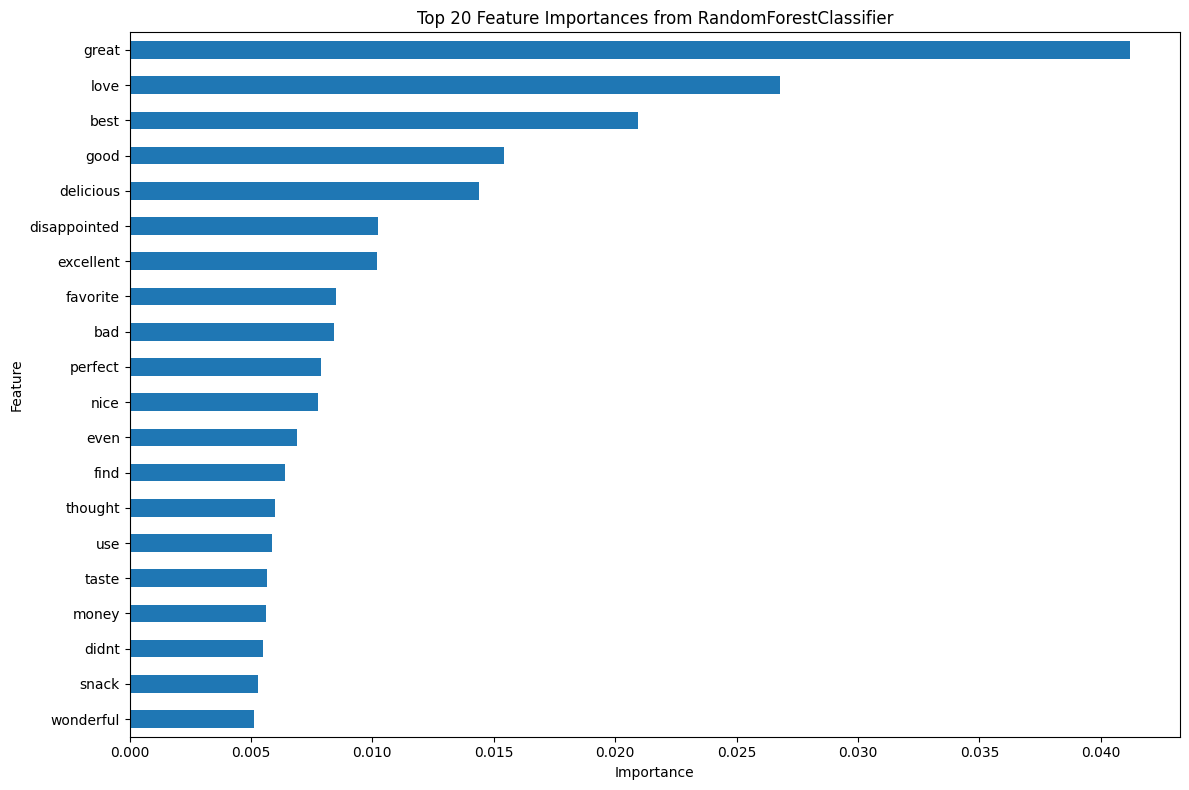

In [51]:
# Plot feature importances
plt.figure(figsize=(12, 8))
top_features.plot(kind='barh')
plt.title('Top 20 Feature Importances from RandomForestClassifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis() # Display highest importance at the top
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

## Task 2 — Handle Class Imbalance

Class imbalance occurs when one class in a dataset has significantly fewer observations than the other. This can lead to models that perform poorly on the minority class, as they tend to be biased towards the majority class. For instance, in our sentiment analysis, if positive reviews are far more numerous than negative reviews, a model might struggle to accurately identify negative sentiment.

We'll check the distribution of our training labels (`y_train`) to see if this is a problem for our current dataset.

In [52]:
# Check the class distribution in the training labels
print("Class distribution in y_train (counts):")
print(y_train.value_counts())

print("\nClass distribution in y_train (percentages):")
print(y_train.value_counts(normalize=True) * 100)

Class distribution in y_train (counts):
Score_Numeric
1    6657
0    1343
Name: count, dtype: int64

Class distribution in y_train (percentages):
Score_Numeric
1    83.2125
0    16.7875
Name: proportion, dtype: float64


As observed, the negative class (0) constitutes only about 16.79% of the training data, indicating a significant class imbalance. This could lead our model to be biased towards predicting the positive class (1).

To address this, we will use techniques to rebalance the dataset. Common strategies include:

*   **Oversampling**: Increasing the number of instances in the minority class (e.g., using SMOTE).
*   **Undersampling**: Decreasing the number of instances in the majority class.

For this task, we will apply **SMOTE (Synthetic Minority Oversampling Technique)** to create synthetic samples of the minority class, thereby balancing the dataset without losing information from the majority class.

In [53]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Display the new class distribution
print("\nClass distribution in y_train after SMOTE (counts):")
print(y_train_resampled.value_counts())

print("\nClass distribution in y_train after SMOTE (percentages):")
print(y_train_resampled.value_counts(normalize=True) * 100)


Class distribution in y_train after SMOTE (counts):
Score_Numeric
0    6657
1    6657
Name: count, dtype: int64

Class distribution in y_train after SMOTE (percentages):
Score_Numeric
0    50.0
1    50.0
Name: proportion, dtype: float64


## Retraining the Model with Balanced Data

After balancing the training data using SMOTE, we will now retrain the `RandomForestClassifier` with the `X_train_resampled` and `y_train_resampled` sets. This ensures that the model learns from a balanced distribution of classes, which should improve its ability to predict both positive and negative sentiments more accurately, especially for the previously underrepresented negative class.

Note: Since SMOTE has already balanced the dataset, we will remove the `class_weight='balanced'` parameter from the `RandomForestClassifier` initialization for this training step, as it's no longer necessary and could potentially overcompensate.

In [57]:
# Initialize and train a new RandomForestClassifier with the resampled training data
# 'class_weight='balanced'' is removed as SMOTE has balanced the data
balanced_model = RandomForestClassifier(n_estimators=100, random_state=42)
balanced_model.fit(X_train_resampled, y_train_resampled)

print("RandomForestClassifier retrained with balanced data successfully.")

RandomForestClassifier retrained with balanced data successfully.


## Evaluating the Retrained Model's Performance

Now that we have retrained the `RandomForestClassifier` on the SMOTE-balanced data, it's crucial to evaluate its performance on the **unseen original test set** (`X_test`, `y_test`). This evaluation will help us understand if the class imbalance handling has improved the model's ability to correctly classify both positive and negative sentiments. We will use:

*   **Classification Report**: Provides precision, recall, and F1-score for each class.
*   **Confusion Matrix**: Shows the counts of true positive, true negative, false positive, and false negative predictions.


Classification Report for Balanced Model (on X_test, y_test):

              precision    recall  f1-score   support

           0       0.74      0.57      0.64       336
           1       0.92      0.96      0.94      1664

    accuracy                           0.89      2000
   macro avg       0.83      0.76      0.79      2000
weighted avg       0.89      0.89      0.89      2000



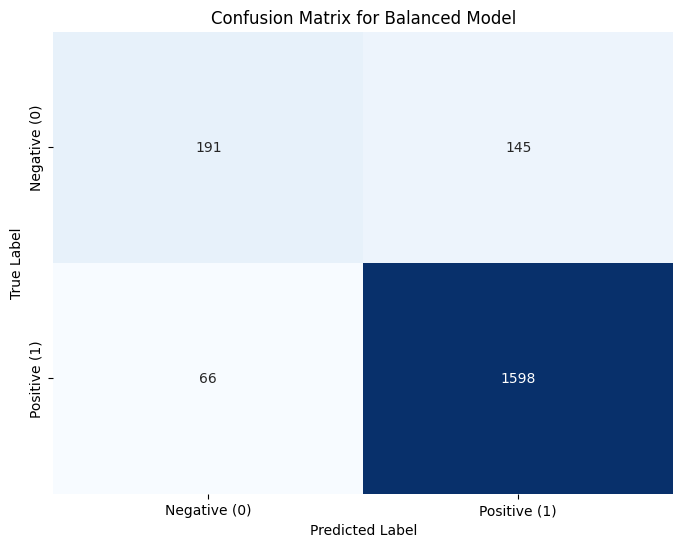

Evaluation complete. The classification report and confusion matrix provide insights into the balanced model's performance.


In [56]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Make predictions on the original test set using the balanced model
y_pred_balanced = balanced_model.predict(X_test)

# Display the classification report
print("\nClassification Report for Balanced Model (on X_test, y_test):\n")
print(classification_report(y_test, y_pred_balanced))

# Display the confusion matrix
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.title('Confusion Matrix for Balanced Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("Evaluation complete. The classification report and confusion matrix provide insights into the balanced model's performance.")

In [9]:
df['Score_Numeric'] = df['Score'].map({'Positive': 1, 'Negative': 0})

## Task 3 — Model Explainability: Understanding Feature Contributions

In [59]:
def explain_prediction(sample_input, model, feature_names):
    """
    Takes one input sample and returns the top 3 most important features
    that influenced the prediction. This function uses the global feature
    importances from the model to infer importance for a single sample.

    sample_input : a single row as a sparse matrix or numpy array
    model        : your trained model (e.g., RandomForestClassifier)
    feature_names: list of column names (e.g., from TfidfVectorizer.get_feature_names_out())
    """
    # Get feature importances from the model
    importances = model.feature_importances_

    # Pair each feature name with its global importance score
    feature_scores = list(zip(feature_names, importances))

    # Sort by importance, highest first
    feature_scores.sort(key=lambda x: x[1], reverse=True)

    # Return the top 3
    top_3 = feature_scores[:3]

    print("Top 3 features influencing this prediction (based on global importance):")
    for i, (name, score) in enumerate(top_3, 1):
        print(f"  {i}. {name}  (importance score: {score:.4f})")

    return top_3

In [60]:
# Test the explain_prediction function with a sample from the test set
# We'll use the 'balanced_model' and the 'feature_names' from 'tfidf_vectorizer'

# Select the first sample from the test set
sample_index = 0
sample_input = X_test[sample_index]

# Get the predicted label for this sample
predicted_label = balanced_model.predict(sample_input)[0]
true_label = y_test.iloc[sample_index]

print(f"Analyzing sample {sample_index}:")
print(f"  True Label: {true_label}")
print(f"  Predicted Label: {predicted_label}")

# Explain the prediction using the function
explain_prediction(sample_input, balanced_model, feature_names)

Analyzing sample 0:
  True Label: 1
  Predicted Label: 1
Top 3 features influencing this prediction (based on global importance):
  1. great  (importance score: 0.0249)
  2. love  (importance score: 0.0179)
  3. disappointed  (importance score: 0.0140)


[('great', np.float64(0.02485837042059416)),
 ('love', np.float64(0.01787120552806089)),
 ('disappointed', np.float64(0.013976693292778126))]

## Task 4 — Domain-Specific Output Enrichment

In [63]:
# Minimum output enrichment for everyone
def format_prediction(y_pred, y_proba, class_labels):
    """
    Converts raw model prediction outputs into a human-readable dictionary.

    y_pred       : The predicted class index (e.g., 0 or 1).
    y_proba      : The array of probabilities for each class (e.g., [0.2, 0.8]).
    class_labels : A list of strings representing the names of the classes
                   in order (e.g., ['Negative', 'Positive']).

    Returns a dictionary with 'prediction' (human-readable label) and
    'confidence' (formatted percentage string).
    """
    label = class_labels[y_pred]
    confidence = f"{max(y_proba) * 100:.1f}%"
    return {
        'prediction': label,
        'confidence': confidence
    }

In [62]:
# Demonstrate the format_prediction function

# Define class labels for our sentiment analysis task
class_labels = ['Negative', 'Positive']

# Let's take the same sample_index = 0 from the test set for consistency
sample_index = 0
sample_input = X_test[sample_index]

# Get the raw prediction (class index) and probabilities for this sample
raw_y_pred = balanced_model.predict(sample_input)[0]
raw_y_proba = balanced_model.predict_proba(sample_input)[0]

# Format the prediction using our new function
enriched_output = format_prediction(raw_y_pred, raw_y_proba, class_labels)

print(f"Raw prediction for sample {sample_index}:")
print(f"  Class Index: {raw_y_pred}")
print(f"  Probabilities: {raw_y_proba}")

print("\nEnriched output:")
print(enriched_output)

# Verify the true label
true_label_numeric = y_test.iloc[sample_index]
true_label_text = class_labels[true_label_numeric]
print(f"\nTrue label for sample {sample_index}: {true_label_text}")

Raw prediction for sample 0:
  Class Index: 1
  Probabilities: [0.25 0.75]

Enriched output:
{'prediction': 'Positive', 'confidence': '75.0%'}

True label for sample 0: Positive


#Task 5:Run 5 Real World sample inputs End to END


In [64]:
import pandas as pd
import numpy as np

def run_full_prediction(raw_input: dict, model, tfidf_vectorizer, clean_text_func, class_labels):
    """
    Takes a raw input dict (as if typed by a user), containing 'Summary' and 'Text',
    runs it through the full pipeline, and returns a human-readable result dict.
    """
    # Step 1: Convert dict to a DataFrame (preserves column names and structure)
    input_df = pd.DataFrame([raw_input])

    # Step 2: Apply the same text preprocessing as training
    input_df['cleaned_summary'] = input_df['Summary'].apply(clean_text_func)
    input_df['cleaned_text'] = input_df['Text'].apply(clean_text_func)
    input_df['Review'] = input_df['cleaned_summary'] + ' ' + input_df['cleaned_text']

    # Step 3: Transform the cleaned review text using the trained TF-IDF vectorizer
    X_processed = tfidf_vectorizer.transform(input_df['Review'])

    # Step 4: Predict
    prediction_index = model.predict(X_processed)[0]
    probability = model.predict_proba(X_processed)[0] if hasattr(model, 'predict_proba') else None

    # Step 5: Enrich output using the format_prediction function (from Task 4)
    # The format_prediction function was defined earlier in the notebook
    enriched_result = format_prediction(prediction_index, probability, class_labels)

    return enriched_result

print("The `run_full_prediction` function is defined.")

The `run_full_prediction` function is defined.


In [65]:
# Define 5 varied and realistic sample review inputs
samples = [
    # Case 1 — Strongly Positive Review
    {
        'Summary': 'Absolutely fantastic!',
        'Text': 'I received this yesterday and it has exceeded all my expectations. The quality is superb and it performs flawlessly. Highly recommend!'
    },
    # Case 2 — Strongly Negative Review
    {
        'Summary': 'Very disappointed',
        'Text': 'This product broke after only a week of use. It\'s cheaply made and a complete waste of money. I would never buy this again.'
    },
    # Case 3 — Neutral/Mixed Sentiment
    {
        'Summary': 'It\'s okay, but not great',
        'Text': 'The product does what it says, but the performance is average. I was expecting a bit more for the price. It\'s not bad, but not amazing either.'
    },
    # Case 4 — Another Positive, emphasizing quality
    {
        'Summary': 'Great quality and value!',
        'Text': 'For the price, you simply cannot beat the quality of this item. It\'s sturdy, well-designed, and has quickly become a household favorite. Excellent purchase.'
    },
    # Case 5 — Mildly Negative/Frustrated
    {
        'Summary': 'Could be better',
        'Text': 'I\'m having some trouble getting this to work as advertised. The instructions are unclear, and it\'s quite frustrating to set up. I hope I can figure it out eventually.'
    }
]

# Define class labels for our sentiment analysis task
class_labels = ['Negative', 'Positive'] # Ensure this matches your model's output mapping

print(f"{'Sample':<10} {'Prediction':<15} {'Confidence'}")
print("-" * 40)
for i, sample in enumerate(samples, 1):
    # Pass the global model, vectorizer, clean_text function, and class_labels
    result = run_full_prediction(sample, balanced_model, tfidf_vectorizer, clean_text, class_labels)
    print(f"Sample {i:<4} {result['prediction']:<15} {result['confidence']}")

# Save the sample inputs for Day 10 testing (optional, but good practice)
# In a real scenario, you might save this to a file.
# For now, we'll keep it as a variable for the notebook state.
saved_samples_for_day10 = samples
print("\nSample inputs saved for Day 10 testing.")

Sample     Prediction      Confidence
----------------------------------------
Sample 1    Positive        76.0%
Sample 2    Negative        60.0%
Sample 3    Positive        85.0%
Sample 4    Positive        93.0%
Sample 5    Positive        82.0%

Sample inputs saved for Day 10 testing.
